In [11]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as pt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv('tennis.csv')
df.head()

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   outlook   14 non-null     object
 1   temp      14 non-null     object
 2   humidity  14 non-null     object
 3   windy     14 non-null     bool  
 4   play      14 non-null     object
dtypes: bool(1), object(4)
memory usage: 594.0+ bytes


In [4]:
dtc = DecisionTreeClassifier(random_state=42, max_depth=3)

X = df.drop(columns=["play"])
y = df["play"]

In [5]:
X = pd.get_dummies(X)
le = LabelEncoder()
y = le.fit_transform(y)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [7]:
X_train = pd.DataFrame(X_train, columns=list(X.columns))
print(X_train)
y_train = pd.Series(y_train)
print(y_train)

    windy  outlook_overcast  outlook_rainy  outlook_sunny  temp_cool  \
12  False              True          False          False      False   
5    True             False           True          False       True   
8   False             False          False           True       True   
2   False              True          False          False      False   
1    True             False          False           True      False   
13   True             False           True          False      False   
4   False             False           True          False       True   
7   False             False          False           True      False   
10   True             False          False           True      False   
3   False             False           True          False      False   
6    True              True          False          False       True   

    temp_hot  temp_mild  humidity_high  humidity_normal  
12      True      False          False             True  
5      False      F

In [8]:
dtc.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

[Text(0.625, 0.875, 'x[1] <= 0.5\ngini = 0.463\nsamples = 11\nvalue = [4, 7]'),
 Text(0.5, 0.625, 'x[7] <= 0.5\ngini = 0.5\nsamples = 8\nvalue = [4, 4]'),
 Text(0.5625, 0.75, 'True  '),
 Text(0.25, 0.375, 'x[0] <= 0.5\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.125, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.125, 'gini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.75, 0.375, 'x[0] <= 0.5\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.625, 0.125, 'gini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.875, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.75, 0.625, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.6875, 0.75, '  False')]

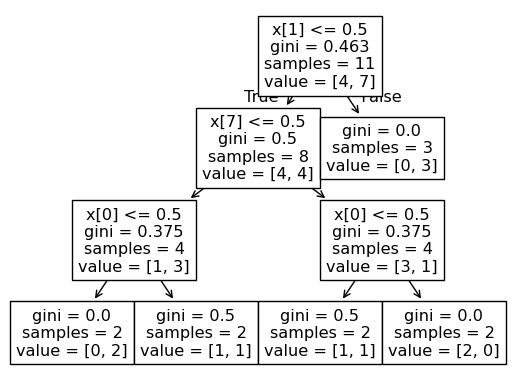

In [10]:
# Example plotting
plot_tree(dtc)

In [26]:
dtc.predict([[1, 0, 1, 0, 1, 0, 0, 1, 0]])
# # No -> 0, Yes -> 1 

/home/Jatin/Documents/test/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


array([0])

In [27]:
ypred = dtc.predict(X_test)

In [28]:
accuracy = accuracy_score(y_test, ypred)
print(f"Accuracy_score : {accuracy}")

Accuracy_score : 1.0
